In [1]:
import MDAnalysis as mda
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
from MDAnalysis.lib.nsgrid import FastNS
from MDAnalysis.lib import mdamath 
from collections import defaultdict
from scipy.spatial import cKDTree
import math
import os
import matplotlib.pyplot as plt

lammps_data = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/lammps.data'
trajectory_file = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/traj.lammpstrj'
u = mda.Universe(lammps_data, trajectory_file, format='LAMMPSDUMP')


/home/user/anaconda3/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [2]:

total_chains = 650              # Set to actual polymer chain count in your system
polymer_type = 1                # Atom type for polymer
receptor_type = 2               # Atom type for receptor

num_bins = 50
max_distance = 50               # Maximum distance sphere radius (Angstrom)
bins = np.linspace(0, max_distance, num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

z_slab = 115.0                  # z where slab starts t(set for your system)
buffer = 0.0   
# Slab region definition
x_min, x_max = -30, 30
y_min, y_max = -30, 30
z_min, z_max = 32.2, 34.# Optionally set >0 to avoid near-boundary artifacts


In [3]:
def any_common_elements(list1, list2):
    set1 = set(list1)
    for element in set1:
        if element in list2:
            return True
    return False

def partner_array(resid_interest, cutoff, universe):
    array_partner = [resid_interest]
    atom_list = universe.select_atoms(f"around {cutoff:.2f} (resid {resid_interest})")
    for atom in atom_list:
        array_partner.append(atom.resid)
    return list(set(array_partner))

def max_clu(u, total_chains):
    partners_list = [partner_array(ele, 3.0, u) for ele in range(1, total_chains + 1)]
    max_length, max_list = 0, []
    for lst in partners_list:
        if len(lst) > max_length:
            max_length = len(lst)
            max_list = lst
    chain_in_cluster = max_list
    for chains in range(total_chains):
        if any_common_elements(chain_in_cluster, partners_list[chains]):
            chain_in_cluster += partners_list[chains]
            chain_in_cluster = list(set(chain_in_cluster))
    return chain_in_cluster

def is_chain_inside_box(chain, box, buffer=0.):
    for atom in chain.atoms:
        x, y, z = atom.position
        if not (buffer < x < box[0] - buffer and buffer < y < box[1] - buffer and buffer < z < box[2] - buffer):
            return False
    return True


Total polymers (fragments): 650
Frame 250: Largest cluster = 639 polymers, fraction = 0.983
Frame 251: Largest cluster = 642 polymers, fraction = 0.988
Frame 252: Largest cluster = 642 polymers, fraction = 0.988
Frame 253: Largest cluster = 642 polymers, fraction = 0.988
Frame 254: Largest cluster = 648 polymers, fraction = 0.997
Frame 255: Largest cluster = 641 polymers, fraction = 0.986
Frame 256: Largest cluster = 640 polymers, fraction = 0.985
Frame 257: Largest cluster = 645 polymers, fraction = 0.992
Frame 258: Largest cluster = 644 polymers, fraction = 0.991
Frame 259: Largest cluster = 635 polymers, fraction = 0.977
Frame 260: Largest cluster = 647 polymers, fraction = 0.995
Frame 261: Largest cluster = 648 polymers, fraction = 0.997
Frame 262: Largest cluster = 638 polymers, fraction = 0.982
Frame 263: Largest cluster = 637 polymers, fraction = 0.980
Frame 264: Largest cluster = 642 polymers, fraction = 0.988
Frame 265: Largest cluster = 641 polymers, fraction = 0.986
Frame 26

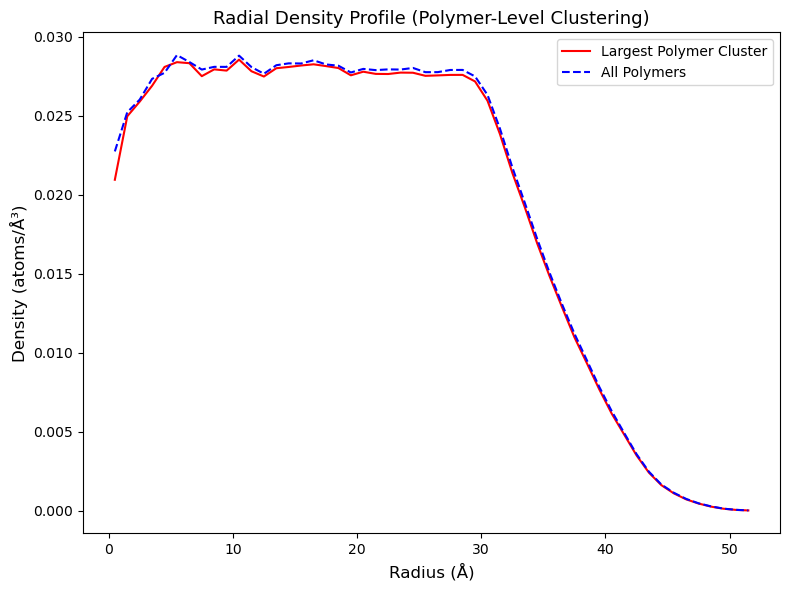

In [4]:
output_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/polymer_cluster_analysis_sphere.csv'
output_table_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/polymer_radial_density_table_sphere.csv'
output_plot = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/radialdensity_polymer_sphere.png'


from MDAnalysis.lib.distances import distance_array

polymer_type = 1
cutoff = 2.5
bin_width = 1.0
max_radius = 30 * math.sqrt(3)

polymers = u.select_atoms(f"type {polymer_type}")

#polymer = fragment
fragments = polymers.fragments
n_polymers = len(fragments)

print(f"Total polymers (fragments): {n_polymers}")

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0]*n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        else:
            self.parent[rb] = ra
            if self.rank[ra] == self.rank[rb]:
                self.rank[ra] += 1

bins = np.arange(0, max_radius + bin_width, bin_width)
V_r = [(4/3) * np.pi * r**3 for r in bins]
shell_volumes = np.array([V_r[i+1] - V_r[i] for i in range(len(V_r)-1)])
bin_centers = 0.5 * (bins[:-1] + bins[1:])

radial_density_cluster = np.zeros(len(shell_volumes))
radial_density_all = np.zeros(len(shell_volumes))
results = []


for ts in u.trajectory[250:399]:

    polymers.wrap(compound='fragments')

    uf = UnionFind(n_polymers)

#polymer polymer neighbor check
    for i in range(n_polymers):
        frag_i = fragments[i]
        for j in range(i+1, n_polymers):
            frag_j = fragments[j]

            dists = distance_array(
                frag_i.positions,
                frag_j.positions,
                box=ts.dimensions
            )

            if np.any(dists <= cutoff):
                uf.union(i, j)

    #Build clusters
    groups = defaultdict(list)
    for i in range(n_polymers):
        groups[uf.find(i)].append(i)

    largest_cluster_polymers = max(groups.values(), key=len)
    largest_cluster_size = len(largest_cluster_polymers)
    fraction = largest_cluster_size / n_polymers

    print(f"Frame {ts.frame}: Largest cluster = {largest_cluster_size} polymers, fraction = {fraction:.3f}")
    results.append([ts.frame, largest_cluster_size, fraction])

    largest_cluster_atoms = mda.AtomGroup(
        np.concatenate([fragments[i].indices for i in largest_cluster_polymers]),
        u
    )

    #cluster
    ref_com_cluster = largest_cluster_atoms.center_of_mass()
    distances_cluster = np.linalg.norm(
        largest_cluster_atoms.positions - ref_com_cluster,
        axis=1
    )
    hist_cluster, _ = np.histogram(distances_cluster, bins=bins)
    radial_density_cluster += hist_cluster

    # all polymers
    ref_com_all = polymers.center_of_mass()
    distances_all = np.linalg.norm(
        polymers.positions - ref_com_all,
        axis=1
    )
    hist_all, _ = np.histogram(distances_all, bins=bins)
    radial_density_all += hist_all

df = pd.DataFrame(results, columns=["Frame", "LargestClusterSize", "Fraction"])
df.to_csv(output_csv, index=False)

n_frames = len(range(0, 399))
radial_density_cluster /= (n_frames * shell_volumes)
radial_density_all /= (n_frames * shell_volumes)

density_df = pd.DataFrame({
    "Radius(Å)": bin_centers,
    "ClusterDensity(atoms/Å³)": radial_density_cluster,
    "AllPolymerDensity(atoms/Å³)": radial_density_all
})
density_df.to_csv(output_table_csv, index=False)

plt.figure(figsize=(8,6))
plt.plot(bin_centers, radial_density_cluster, label="Largest Polymer Cluster", color='r')
plt.plot(bin_centers, radial_density_all, label="All Polymers", color='b', linestyle='--')
plt.xlabel("Radius (Å)", fontsize=12)
plt.ylabel("Density (atoms/Å³)", fontsize=12)
plt.title("Radial Density Profile (Polymer-Level Clustering)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

Frame 0: Largest cluster = 15850 | Fraction = 0.975
Frame 1: Largest cluster = 16125 | Fraction = 0.992
Frame 2: Largest cluster = 16100 | Fraction = 0.991
Frame 3: Largest cluster = 16100 | Fraction = 0.991
Frame 4: Largest cluster = 16225 | Fraction = 0.998
Frame 5: Largest cluster = 15975 | Fraction = 0.983
Frame 6: Largest cluster = 16000 | Fraction = 0.985
Frame 7: Largest cluster = 15925 | Fraction = 0.980
Frame 8: Largest cluster = 15950 | Fraction = 0.982
Frame 9: Largest cluster = 16075 | Fraction = 0.989
Frame 10: Largest cluster = 16050 | Fraction = 0.988
Frame 11: Largest cluster = 16100 | Fraction = 0.991
Frame 12: Largest cluster = 16025 | Fraction = 0.986
Frame 13: Largest cluster = 16100 | Fraction = 0.991
Frame 14: Largest cluster = 16075 | Fraction = 0.989
Frame 15: Largest cluster = 16150 | Fraction = 0.994
Frame 16: Largest cluster = 15950 | Fraction = 0.982
Frame 17: Largest cluster = 16000 | Fraction = 0.985
Frame 18: Largest cluster = 16075 | Fraction = 0.989
Fra

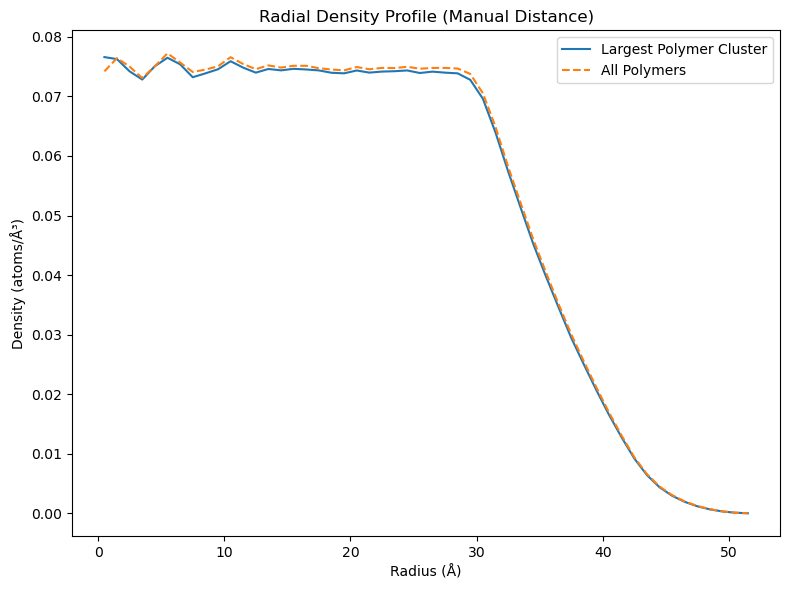

In [3]:
output_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/polymer_cluster_analysis_sphere.csv'
output_table_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/polymer_radial_density_table_sphere.csv'
output_plot = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/radialdensity_polymer_sphere.png'

polymer_type = 1
cutoff = 2.5
bin_width = 1.0

polymers = u.select_atoms(f"type {polymer_type}")
total_polymers = len(polymers)

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0]*n

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        else:
            self.parent[rb] = ra
            if self.rank[ra] == self.rank[rb]:
                self.rank[ra] += 1

def get_cell_index(pos, cell_size):
    return tuple((pos // cell_size).astype(int))

max_radius = 30 * math.sqrt(3)
bins = np.arange(0, max_radius + bin_width, bin_width)

V_r = [(4/3)*math.pi*r**3 for r in bins]
shell_volumes = np.array([V_r[i+1] - V_r[i] for i in range(len(V_r)-1)])
bin_centers = 0.5 * (bins[:-1] + bins[1:])

radial_density_cluster = np.zeros(len(shell_volumes))
radial_density_all = np.zeros(len(shell_volumes))

results = []


for ts in u.trajectory[0:399]:

    polymers.wrap(compound='fragments')
    positions = polymers.positions
    box = ts.dimensions[:3]

    cell_size = cutoff
    ncell = (box / cell_size).astype(int)

    cell_dict = defaultdict(list)
    for i, pos in enumerate(positions):
        cell = get_cell_index(pos, cell_size)
        cell_dict[cell].append(i)

    neighbor_offsets = [(dx,dy,dz) 
                        for dx in [-1,0,1]
                        for dy in [-1,0,1]
                        for dz in [-1,0,1]]

    pairs = set()
    
    for cell, atom_ids in cell_dict.items():
        for dx,dy,dz in neighbor_offsets:
            neigh = ((cell[0]+dx) % ncell[0],
                     (cell[1]+dy) % ncell[1],
                     (cell[2]+dz) % ncell[2])
    
            for i in atom_ids:
                for j in cell_dict.get(neigh, []):
                    if i == j:
                        continue
    
                    a, b = min(i, j), max(i, j)
    
                    dx = positions[a][0] - positions[b][0]
                    dy = positions[a][1] - positions[b][1]
                    dz = positions[a][2] - positions[b][2]
    
                    dx -= box[0] * round(dx / box[0])
                    dy -= box[1] * round(dy / box[1])
                    dz -= box[2] * round(dz / box[2])
    
                    if dx*dx + dy*dy + dz*dz <= cutoff*cutoff:
                        pairs.add((a, b))

    # Cluster detection 
    uf = UnionFind(total_polymers)
    for i, j in pairs:
        uf.union(i, j)

    groups = defaultdict(list)
    for i in range(total_polymers):
        groups[uf.find(i)].append(i)

    largest_cluster = max(groups.values(), key=len)
    fraction = len(largest_cluster) / total_polymers

    print(f"Frame {ts.frame}: Largest cluster = {len(largest_cluster)} | Fraction = {fraction:.3f}")
    results.append([ts.frame, len(largest_cluster), fraction])


    cluster_positions = positions[largest_cluster]
    ref_com_cluster = cluster_positions.mean(axis=0)

    hist_cluster = np.zeros(len(bins)-1)
    for pos in cluster_positions:
        dx = pos[0] - ref_com_cluster[0]
        dy = pos[1] - ref_com_cluster[1]
        dz = pos[2] - ref_com_cluster[2]
        r = math.sqrt(dx*dx + dy*dy + dz*dz)

        bin_id = int(r // bin_width)
        if bin_id < len(hist_cluster):
            hist_cluster[bin_id] += 1

    radial_density_cluster += hist_cluster

    # ---- All polymers ----
    ref_com_all = polymers.center_of_mass()
    hist_all = np.zeros(len(bins)-1)

    for pos in positions:
        dx = pos[0] - ref_com_all[0]
        dy = pos[1] - ref_com_all[1]
        dz = pos[2] - ref_com_all[2]
        r = math.sqrt(dx*dx + dy*dy + dz*dz)

        bin_id = int(r // bin_width)
        if bin_id < len(hist_all):
            hist_all[bin_id] += 1

    radial_density_all += hist_all

df = pd.DataFrame(results, columns=["Frame", "LargestClusterSize", "Fraction"])
df.to_csv(output_csv, index=False)

n_frames = len(range(0,399))
radial_density_cluster /= (n_frames * shell_volumes)
radial_density_all /= (n_frames * shell_volumes)

density_df = pd.DataFrame({
    "Radius(Å)": bin_centers,
    "ClusterDensity(atoms/Å³)": radial_density_cluster,
    "AllPolymerDensity(atoms/Å³)": radial_density_all
})
density_df.to_csv(output_table_csv, index=False)

plt.figure(figsize=(8,6))
plt.plot(bin_centers, radial_density_cluster, label="Largest Polymer Cluster")
plt.plot(bin_centers, radial_density_all, '--', label="All Polymers")
plt.xlabel("Radius (Å)")
plt.ylabel("Density (atoms/Å³)")
plt.title("Radial Density Profile (Manual Distance)")
plt.legend()
plt.tight_layout()
plt.savefig(output_plot, dpi=300)
plt.show()


Frame 0: largest receptor cluster = 40 atoms, fraction = 0.200
Frame 1: largest receptor cluster = 91 atoms, fraction = 0.455
Frame 2: largest receptor cluster = 85 atoms, fraction = 0.425
Frame 3: largest receptor cluster = 80 atoms, fraction = 0.400
Frame 4: largest receptor cluster = 86 atoms, fraction = 0.430
Frame 5: largest receptor cluster = 91 atoms, fraction = 0.455
Frame 6: largest receptor cluster = 100 atoms, fraction = 0.500
Frame 7: largest receptor cluster = 140 atoms, fraction = 0.700
Frame 8: largest receptor cluster = 158 atoms, fraction = 0.790
Frame 9: largest receptor cluster = 150 atoms, fraction = 0.750
Frame 10: largest receptor cluster = 152 atoms, fraction = 0.760
Frame 11: largest receptor cluster = 148 atoms, fraction = 0.740
Frame 12: largest receptor cluster = 132 atoms, fraction = 0.660
Frame 13: largest receptor cluster = 147 atoms, fraction = 0.735
Frame 14: largest receptor cluster = 153 atoms, fraction = 0.765
Frame 15: largest receptor cluster = 155 

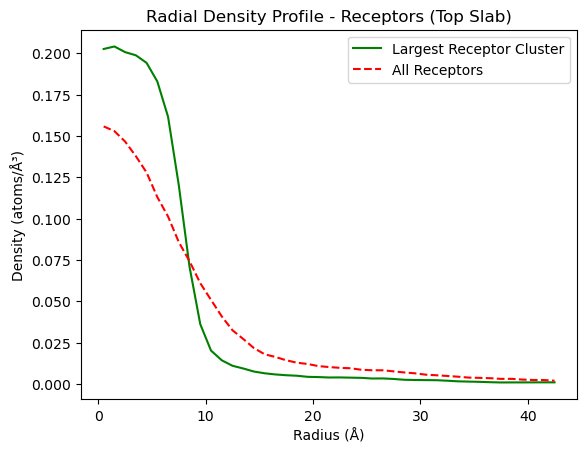

In [5]:
output_frame_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/receptor_radial_density.csv'
output_density_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/receptor_radial_density_table.csv'
output_plot = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_200/receptor_radial_density.png'

receptor_type = 2
cutoff = 2.5
bin_width = 1.0
max_radius = 30.0 * math.sqrt(2)
slab_thickness = 2.6

u = mda.Universe(lammps_data, trajectory_file, format='LAMMPSDUMP')

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        else:
            self.parent[rb] = ra
            if self.rank[ra] == self.rank[rb]:
                self.rank[ra] += 1

def get_cell_index(pos, cell_size, box):
    return tuple((pos // cell_size).astype(int))

bins = np.arange(0, max_radius + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
shell_volumes = np.pi * slab_thickness * (bins[1:]**2 - bins[:-1]**2)

radial_density_cluster = np.zeros(len(shell_volumes))
radial_density_all = np.zeros(len(shell_volumes))
valid_frames = 0
frame_results = []

for ts in u.trajectory:
    Lz = ts.dimensions[2]
    receptors = u.select_atoms(f"type {receptor_type} and prop z>{Lz - slab_thickness}")
    total_receptors = len(receptors)
    if total_receptors == 0:
        continue

    receptors.wrap(compound='fragments')
    positions = receptors.positions
    box = ts.dimensions[:3]
    cell_size = cutoff
    cell_dict = defaultdict(list)
    for i, pos in enumerate(positions):
        cell = get_cell_index(pos, cell_size, box)
        cell_dict[cell].append(i)

    neighbor_offsets = [(dx, dy, dz) for dx in [-1, 0, 1] for dy in [-1, 0, 1] for dz in [-1, 0, 1]]
    pairs = []
    for cell, atom_ids in cell_dict.items():
        for dx, dy, dz in neighbor_offsets:
            neighbor_cell = (
                (cell[0] + dx) % int(box[0] / cell_size),
                (cell[1] + dy) % int(box[1] / cell_size),
                (cell[2] + dz) % int(box[2] / cell_size)
            )
            for i in atom_ids:
                for j in cell_dict.get(neighbor_cell, []):
                    if j <= i:
                        continue
                    diff = positions[i] - positions[j]
                    diff -= box * np.round(diff / box)
                    if np.dot(diff, diff) <= cutoff**2:
                        pairs.append((i, j))

    uf = UnionFind(total_receptors)
    for i, j in pairs:
        uf.union(i, j)

    groups = defaultdict(list)
    for i in range(total_receptors):
        groups[uf.find(i)].append(i)

    largest_cluster = max(groups.values(), key=len)
    fraction = len(largest_cluster) / total_receptors
    print(f"Frame {ts.frame}: largest receptor cluster = {len(largest_cluster)} atoms, fraction = {fraction:.3f}")

    frame_results.append([ts.frame, total_receptors, len(largest_cluster), fraction])

    cluster_positions = positions[largest_cluster]
    ref_com_cluster = cluster_positions.mean(axis=0)
    distances_cluster = np.linalg.norm(cluster_positions[:, :2] - ref_com_cluster[:2], axis=1)
    hist_cluster, _ = np.histogram(distances_cluster, bins=bins)
    radial_density_cluster += hist_cluster

    ref_com_all = receptors.center_of_mass()
    distances_all = np.linalg.norm(positions[:, :2] - ref_com_all[:2], axis=1)
    hist_all, _ = np.histogram(distances_all, bins=bins)
    radial_density_all += hist_all

    valid_frames += 1

df_frame = pd.DataFrame(frame_results, columns=["Frame", "TotalReceptors", "LargestClusterSize", "Fraction"])
df_frame.to_csv(output_frame_csv, index=False)

radial_density_cluster /= (valid_frames * shell_volumes)
radial_density_all /= (valid_frames * shell_volumes)

density_table = pd.DataFrame({
    "Radius (Å)": bin_centers,
    "Cluster Density (atoms/Å³)": radial_density_cluster,
    "All Receptors Density (atoms/Å³)": radial_density_all
})
density_table.to_csv(output_density_csv, index=False)

plt.plot(bin_centers, radial_density_cluster, label="Largest Receptor Cluster", color='g')
plt.plot(bin_centers, radial_density_all, label="All Receptors", color='r', linestyle='--')
plt.xlabel("Radius (Å)")
plt.ylabel("Density (atoms/Å³)")
plt.legend()
plt.title("Radial Density Profile - Receptors (Top Slab)")
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()


In [160]:
print(df.columns.tolist())

['Frame', 'Num_Receptors', 'LargestClusterSize', 'Fraction']


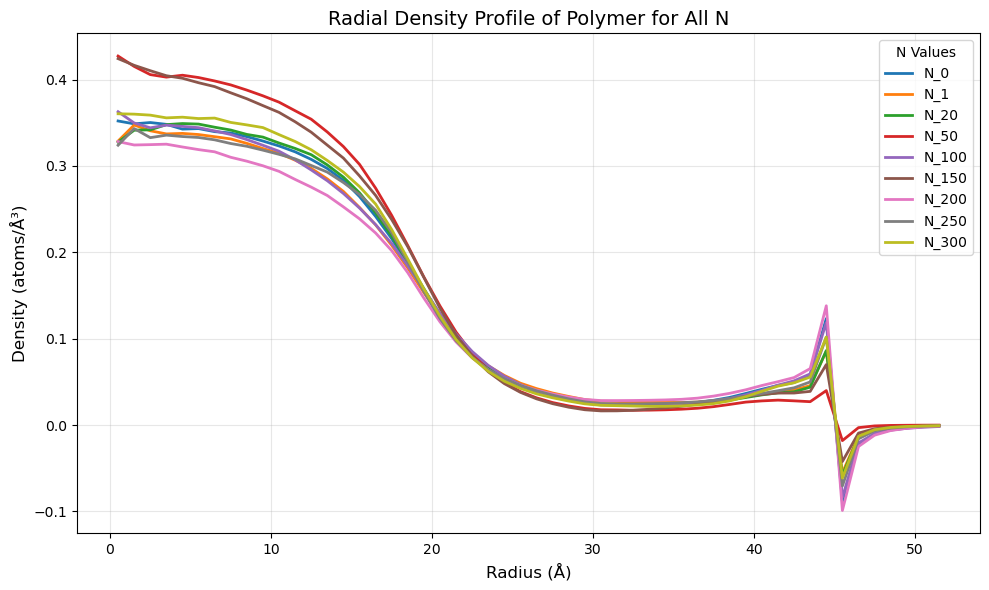


 Combined plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/all_N_radial_density_plot.png


In [25]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Automatically detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_radial_density_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_radial_density_table.csv')
    
    # Check if CSV exists
    if not os.path.isfile(csv_file):
        print(f" CSV not found in {folder_path}, skipping...")
        continue
    
    # Load CSV
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f" Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    if 'Radius(Å)' not in df.columns or 'ClusterDensity(atoms/Å³)' not in df.columns:
        print(f" Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius(Å)']
    cluster_density = df['ClusterDensity(atoms/Å³)']
    
    # Plot
    plt.plot(radius, cluster_density, label=n, linewidth=2)

# Plot formatting
plt.xlabel('Radius (Å)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.title('Radial Density Profile of Polymer for All N', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined plot saved at: {output_plot}")


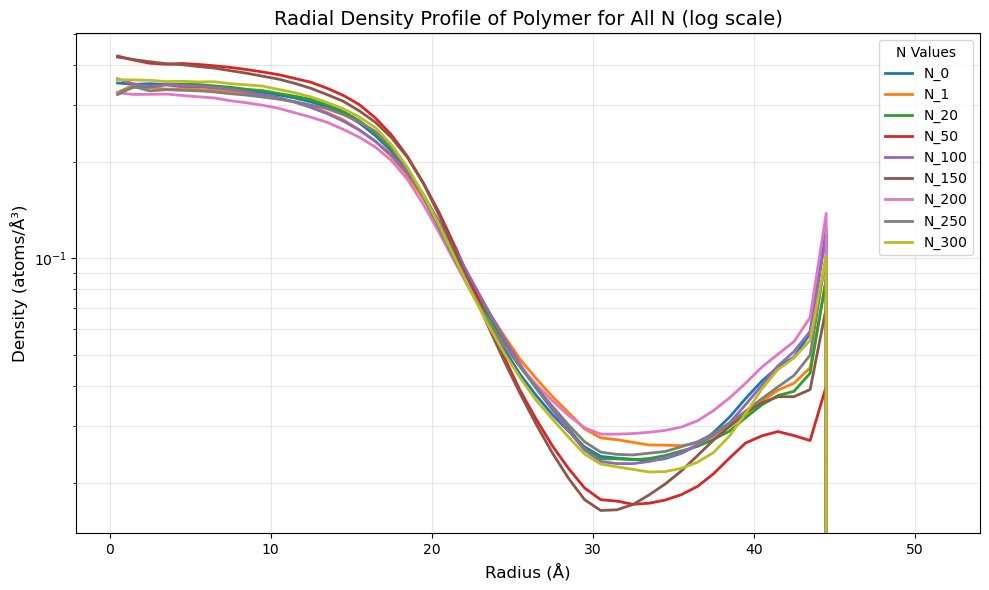


 Combined plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/all_N_radial_density_plot_log.png


In [26]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Automatically detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_radial_density_plot_log.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_radial_density_table.csv')
    
    # Check if CSV exists
    if not os.path.isfile(csv_file):
        print(f" CSV not found in {folder_path}, skipping...")
        continue
    
    # Load CSV
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f" Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    if 'Radius(Å)' not in df.columns or 'ClusterDensity(atoms/Å³)' not in df.columns:
        print(f" Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius(Å)']
    cluster_density = df['ClusterDensity(atoms/Å³)']

    plt.plot(radius, cluster_density, label=n, linewidth=2)

plt.xlabel('Radius (Å)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.yscale('log')  # Set y-axis to log scale
plt.title('Radial Density Profile of Polymer for All N (log scale)', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3, which='both')  # grid for both major and minor ticks
plt.tight_layout()

plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined plot saved at: {output_plot}")


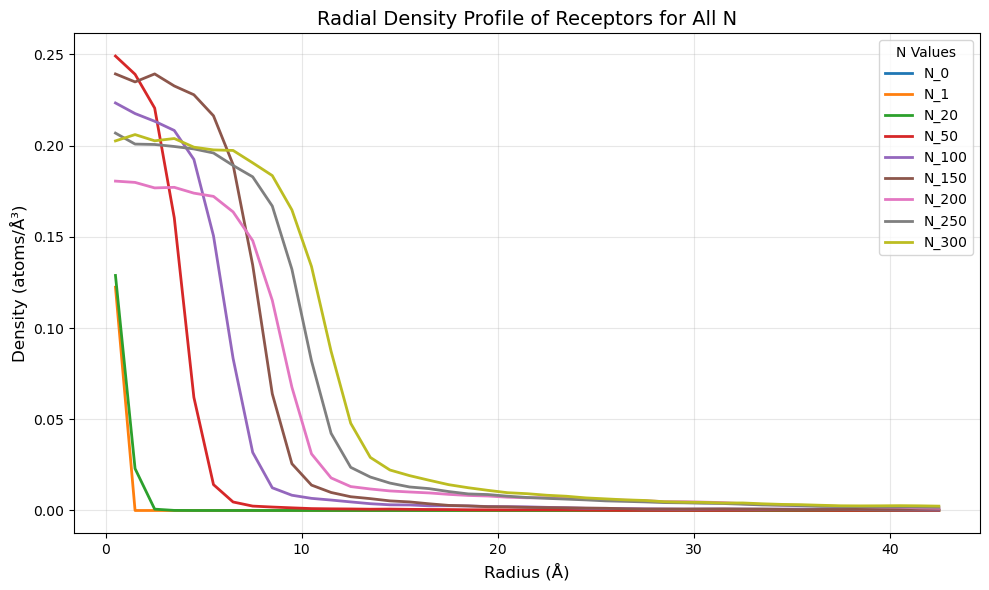


 Combined receptor plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/all_N_receptor_radial_density_plot.png


In [27]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
# Sort numerically by the number after N_
n_folders.sort(key=lambda x: int(x.split('_')[1]))

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_receptor_radial_density_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density_table.csv')
    
    if not os.path.isfile(csv_file):
        print(f" CSV not found in {folder_path}, skipping...")
        continue
    
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f" Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    required_cols = ['Radius (Å)', 'Cluster Density (atoms/Å³)']
    if not all(col in df.columns for col in required_cols):
        print(f" Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius (Å)']
    cluster_density = df['Cluster Density (atoms/Å³)']
    
    # Plot cluster density
    plt.plot(radius, cluster_density, label=n, linewidth=2)

# Plot formatting
plt.xlabel('Radius (Å)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.title('Radial Density Profile of Receptors for All N', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show plot
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined receptor plot saved at: {output_plot}")


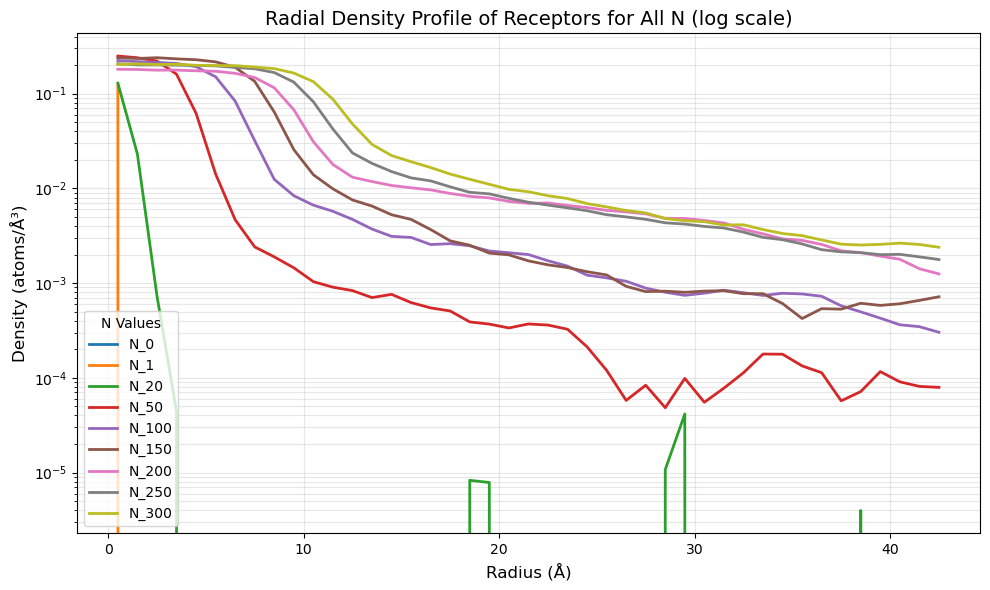


Combined receptor plot (log scale) saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/all_N_receptor_radial_density_log_plot.png


In [28]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
# Sort numerically by the number after N_
n_folders.sort(key=lambda x: int(x.split('_')[1]))

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_receptor_radial_density_log_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density_table.csv')
    
    if not os.path.isfile(csv_file):
        print(f"CSV not found in {folder_path}, skipping...")
        continue
    
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    required_cols = ['Radius (Å)', 'Cluster Density (atoms/Å³)']
    if not all(col in df.columns for col in required_cols):
        print(f"Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius (Å)']
    cluster_density = df['Cluster Density (atoms/Å³)']

    plt.plot(radius, cluster_density, label=n, linewidth=2)

plt.xlabel('Radius (Å)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.yscale('log')  # Log scale for y-axis
plt.title('Radial Density Profile of Receptors for All N (log scale)', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()

plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCombined receptor plot (log scale) saved at: {output_plot}")


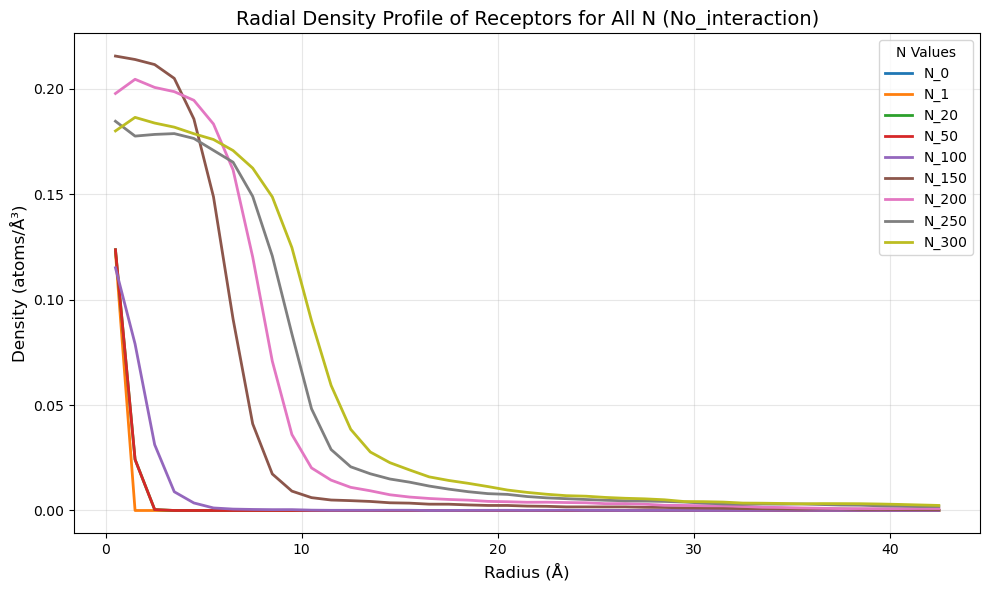


 Combined receptor plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/all_N_receptor_radial_density_plot.png


In [29]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction'

# Detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
# Sort numerically by the number after N_
n_folders.sort(key=lambda x: int(x.split('_')[1]))

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_receptor_radial_density_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density_table.csv')
    
    if not os.path.isfile(csv_file):
        print(f" CSV not found in {folder_path}, skipping...")
        continue
    
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f" Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    required_cols = ['Radius (Å)', 'Cluster Density (atoms/Å³)']
    if not all(col in df.columns for col in required_cols):
        print(f" Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius (Å)']
    cluster_density = df['Cluster Density (atoms/Å³)']
    
    # Plot cluster density
    plt.plot(radius, cluster_density, label=n, linewidth=2)

# Plot formatting
plt.xlabel('Radius (Å)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.title('Radial Density Profile of Receptors for All N (No_interaction)', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show plot
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()delete_atoms random count 75 no ligand NULL 32

print(f"\n Combined receptor plot saved at: {output_plot}")


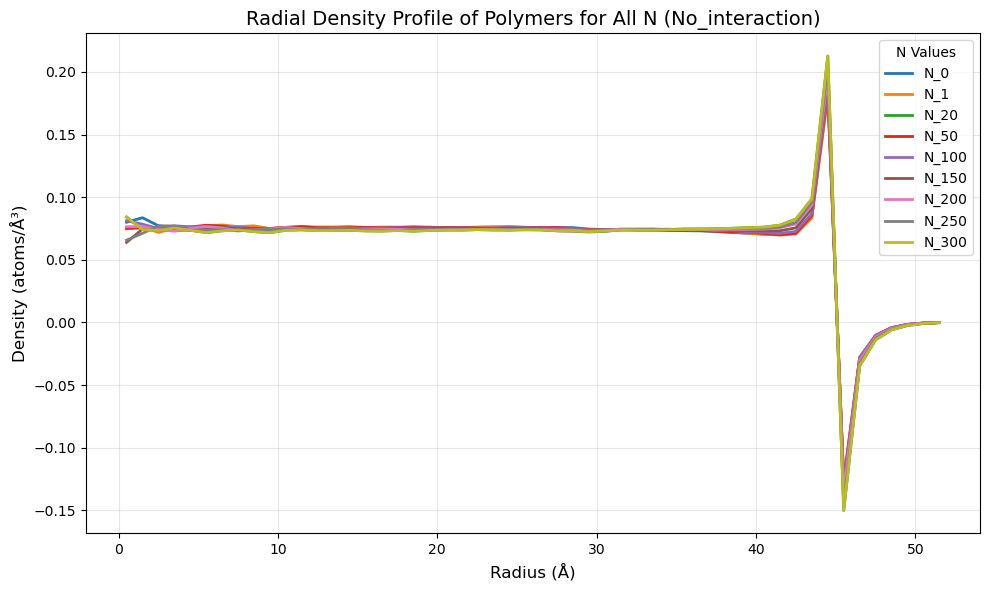


 Combined polymer plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/all_N_polymer_radial_density_plot.png


In [30]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction'

# Detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
# Sort numerically by the number after N_
n_folders.sort(key=lambda x: int(x.split('_')[1]))

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_polymer_radial_density_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_radial_density_table.csv')
    
    if not os.path.isfile(csv_file):
        print(f"CSV not found in {folder_path}, skipping...")
        continue
    
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    required_cols = ['Radius(Å)', 'ClusterDensity(atoms/Å³)']
    if not all(col in df.columns for col in required_cols):
        print(f"Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius(Å)']
    cluster_density = df['ClusterDensity(atoms/Å³)']
    
    # Plot cluster density
    plt.plot(radius, cluster_density, label=n, linewidth=2)

# Plot formatting
plt.xlabel('Radius (Å)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.title('Radial Density Profile of Polymers for All N (No_interaction)', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show plot
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined polymer plot saved at: {output_plot}")


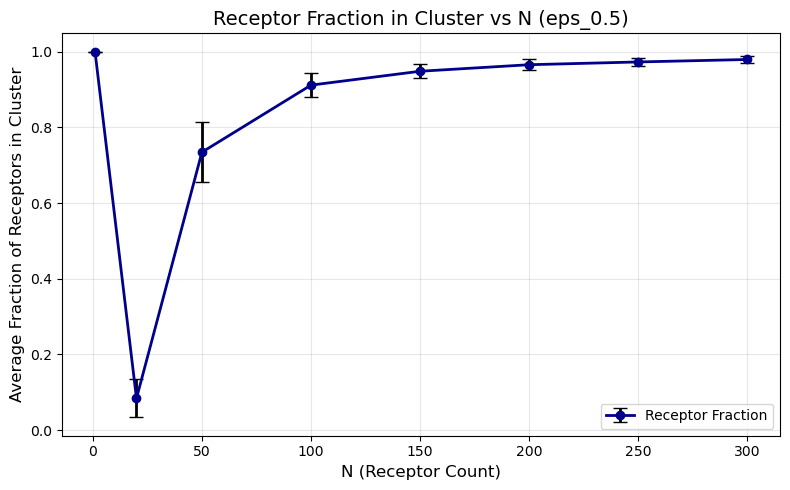


 Receptor fraction vs N (with error bars) saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/receptor_fraction_vs_N_errorbars.png


In [17]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Get all subfolders like N_1, N_20, N_50 ...
n_folders = [f for f in os.listdir(root_folder)
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort by numeric N value

n_values = []
avg_fractions = []
std_fractions = []  # standard deviation for error bars

for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density.csv')

    if not os.path.isfile(csv_file):
        print(f"Missing file: {csv_file}")
        continue

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue

    if 'Fraction' not in df.columns:
        print(f"No 'Fraction' column found in {csv_file}")
        continue

    # Compute mean and std of receptor fraction
    avg_fraction = df['Fraction'].mean()
    std_fraction = df['Fraction'].std()
    n_value = int(n.split('_')[1])

    n_values.append(n_value)
    avg_fractions.append(avg_fraction)
    std_fractions.append(std_fraction)

# --- Plot Fraction vs N with error bars ---
plt.figure(figsize=(8,5))
plt.errorbar(n_values, avg_fractions, yerr=std_fractions, fmt='o-', color='darkblue',
             ecolor='black', capsize=5, linewidth=2, label='Receptor Fraction')

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Receptors in Cluster', fontsize=12)
plt.title('Receptor Fraction in Cluster vs N (eps_0.5)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
output_plot = os.path.join(root_folder, 'receptor_fraction_vs_N_errorbars.png')
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Receptor fraction vs N (with error bars) saved to:\n{output_plot}")

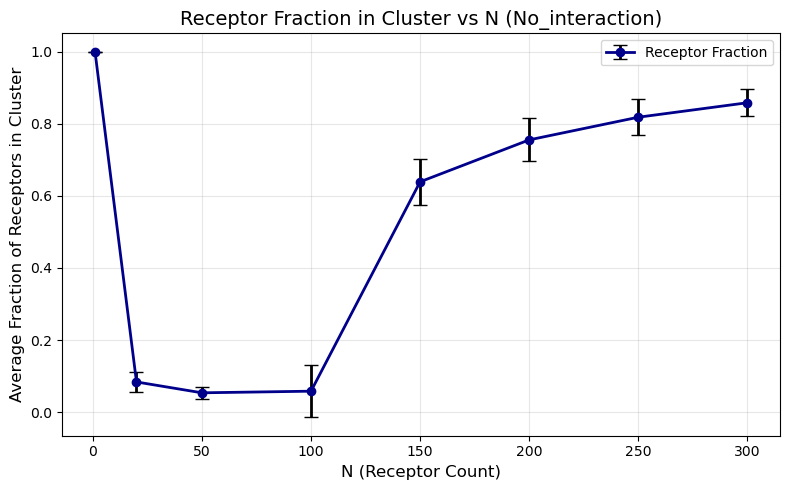


 Receptor fraction vs N (with error bars) saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/receptor_fraction_vs_N_errorbars.png


In [18]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction'

# Get all subfolders like N_1, N_20, N_50 ...
n_folders = [f for f in os.listdir(root_folder)
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort by numeric N value

n_values = []
avg_fractions = []
std_fractions = []  # standard deviation for error bars

for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density.csv')

    if not os.path.isfile(csv_file):
        print(f"Missing file: {csv_file}")
        continue

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue

    if 'Fraction' not in df.columns:
        print(f"No 'Fraction' column found in {csv_file}")
        continue

    # Compute mean and std of receptor fraction
    avg_fraction = df['Fraction'].mean()
    std_fraction = df['Fraction'].std()
    n_value = int(n.split('_')[1])

    n_values.append(n_value)
    avg_fractions.append(avg_fraction)
    std_fractions.append(std_fraction)

# --- Plot Fraction vs N with error bars ---
plt.figure(figsize=(8,5))
plt.errorbar(n_values, avg_fractions, yerr=std_fractions, fmt='o-', color='darkblue',
             ecolor='black', capsize=5, linewidth=2, label='Receptor Fraction')

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Receptors in Cluster', fontsize=12)
plt.title('Receptor Fraction in Cluster vs N (No_interaction)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
output_plot = os.path.join(root_folder, 'receptor_fraction_vs_N_errorbars.png')
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Receptor fraction vs N (with error bars) saved to:\n{output_plot}")

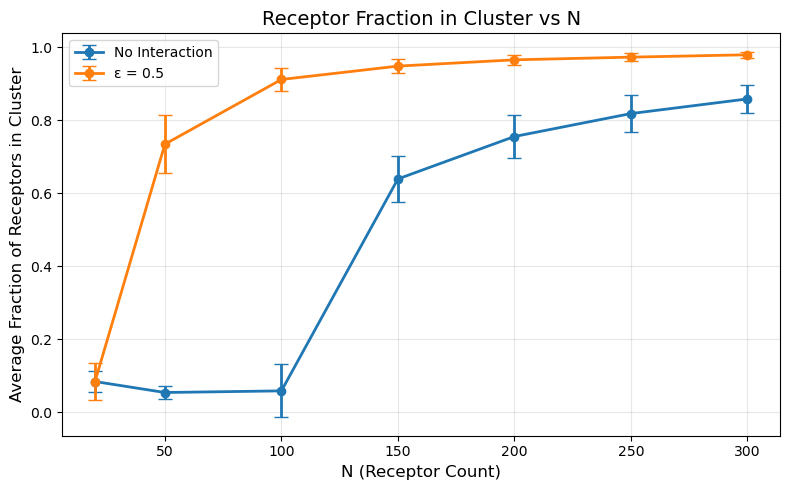


 Combined receptor fraction vs N plot saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/receptor_fraction_vs_N_combined.png


In [20]:
root_folders = {
    'No Interaction': '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction',
    'ε = 0.5': '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'
}

plt.figure(figsize=(8, 5))

# --- Loop over each root and plot ---
for label, root_folder in root_folders.items():
    # Get all subfolders like N_1, N_20, N_50 ...
    n_folders = [
        f for f in os.listdir(root_folder)
        if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)
    ]
    n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically by N

    n_values = []
    avg_fractions = []
    std_fractions = []    # standard deviation for error bars

    for n in n_folders:
        if n == "N_1":  
            continue
        folder_path = os.path.join(root_folder, n)
        csv_file = os.path.join(folder_path, 'receptor_radial_density.csv')

        if not os.path.isfile(csv_file):
            print(f"Missing file: {csv_file}")
            continue

        try:
            df = pd.read_csv(csv_file)
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")
            continue

        if 'Fraction' not in df.columns:
            print(f"No 'Fraction' column found in {csv_file}")
            continue

        # Mean and standard deviation
        avg_fraction = df['Fraction'].mean()
        std_fraction = df['Fraction'].std()
        n_value = int(n.split('_')[1])

        n_values.append(n_value)
        avg_fractions.append(avg_fraction)
        std_fractions.append(std_fraction)

    # Plot with error bars
    plt.errorbar(
        n_values, avg_fractions, yerr=std_fractions,
        fmt='o-', capsize=5, linewidth=2, label=label
    )

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Receptors in Cluster', fontsize=12)
plt.title('Receptor Fraction in Cluster vs N', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

output_plot = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/receptor_fraction_vs_N_combined.png'
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined receptor fraction vs N plot saved to:\n{output_plot}")

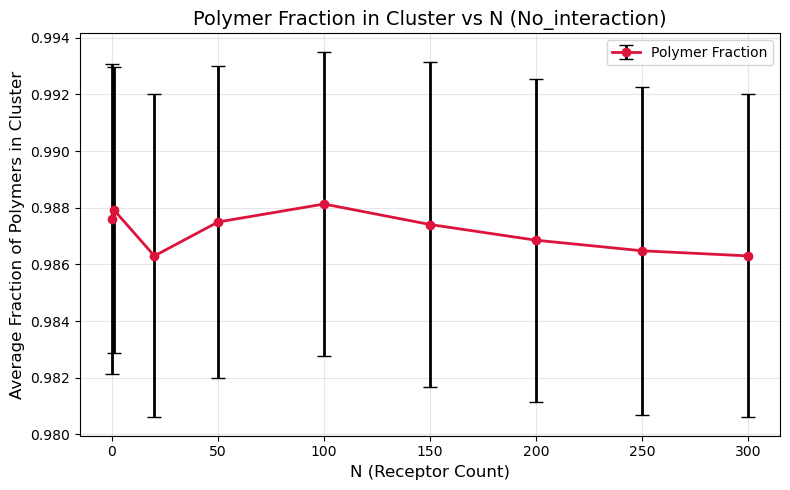


 Polymer fraction vs N (with error bars) saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/fraction_vs_N_polymer_errorbars.png


In [24]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction'

# Identify subfolders named N_*
n_folders = [f for f in os.listdir(root_folder)
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically by N value

n_values = []
avg_fractions = []
std_fractions = []  # standard deviation for error bars

for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_cluster_analysis.csv')https://www.pnas.org/doi/epdf/10.1073/pnas.2017184118

    if not os.path.isfile(csv_file):
        print(f"Missing file: {csv_file}")
        continue

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue

    if 'Fraction' not in df.columns:
        print(f"No 'Fraction' column found in {csv_file}")
        continue

    # Compute mean and standard deviation of fraction for this N
    avg_fraction = df['Fraction'].mean()
    std_fraction = df['Fraction'].std()
    n_value = int(n.split('_')[1])

    n_values.append(n_value)
    avg_fractions.append(avg_fraction)
    std_fractions.append(std_fraction)

# --- Plot Fraction vs N with error bars ---
plt.figure(figsize=(8, 5))
plt.errorbar(n_values, avg_fractions, yerr=std_fractions, fmt='o-', color='crimson',
             ecolor='black', capsize=5, linewidth=2, label='Polymer Fraction')

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Polymers in Cluster', fontsize=12)
plt.title('Polymer Fraction in Cluster vs N (No_interaction)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
output_plot = os.path.join(root_folder, 'fraction_vs_N_polymer_errorbars.png')
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Polymer fraction vs N (with error bars) saved to:\n{output_plot}")

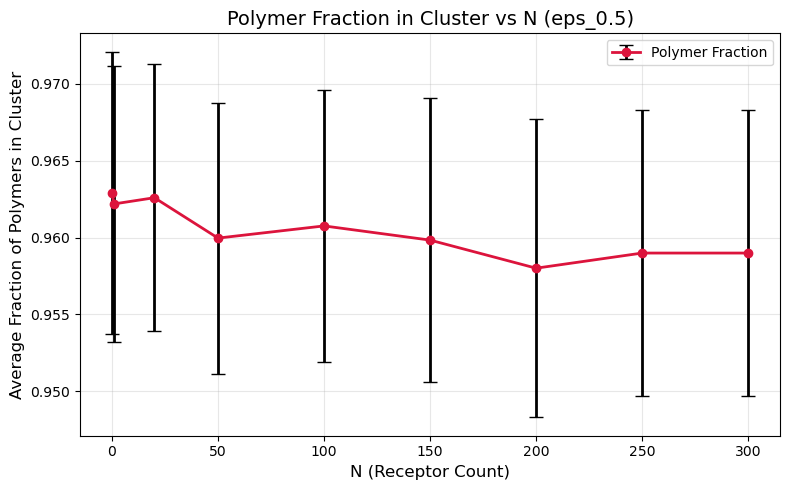


 Polymer fraction vs N (with error bars) saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/fraction_vs_N_polymer_errorbars.png


In [25]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Identify subfolders named N_*
n_folders = [f for f in os.listdir(root_folder)
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically by N value

n_values = []
avg_fractions = []
std_fractions = []  # standard deviation for error bars

for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_cluster_analysis.csv')

    if not os.path.isfile(csv_file):
        print(f"Missing file: {csv_file}")
        continue

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue

    if 'Fraction' not in df.columns:
        print(f"No 'Fraction' column found in {csv_file}")
        continue

    # Compute mean and standard deviation of fraction for this N
    avg_fraction = df['Fraction'].mean()
    std_fraction = df['Fraction'].std()
    n_value = int(n.split('_')[1])

    n_values.append(n_value)
    avg_fractions.append(avg_fraction)
    std_fractions.append(std_fraction)

# --- Plot Fraction vs N with error bars ---
plt.figure(figsize=(8, 5))
plt.errorbar(n_values, avg_fractions, yerr=std_fractions, fmt='o-', color='crimson',
             ecolor='black', capsize=5, linewidth=2, label='Polymer Fraction')

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Polymers in Cluster', fontsize=12)
plt.title('Polymer Fraction in Cluster vs N (eps_0.5)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
output_plot = os.path.join(root_folder, 'fraction_vs_N_polymer_errorbars.png')
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Polymer fraction vs N (with error bars) saved to:\n{output_plot}")



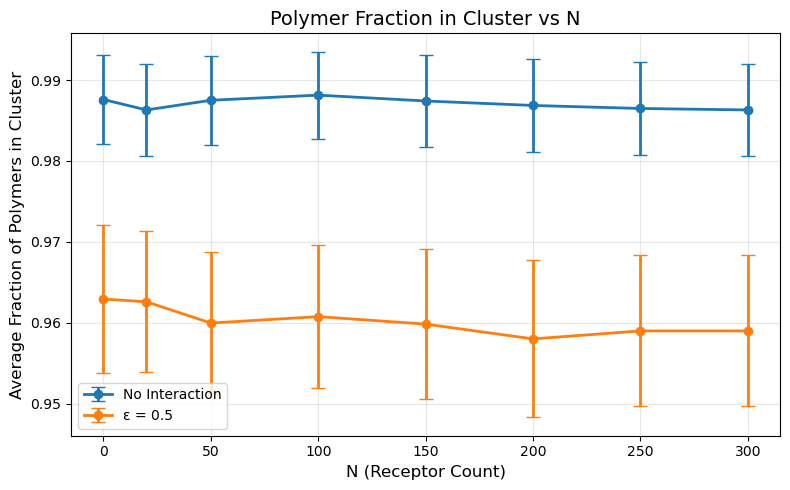


Combined polymer fraction vs N plot saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/polymer_fraction_vs_N_combined.png


In [26]:
root_folders = {
    'No Interaction': '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction',
    'ε = 0.5': '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'
}

plt.figure(figsize=(8, 5))

# --- Loop over each root and plot ---
for label, root_folder in root_folders.items():
    # Identify subfolders like N_1, N_20, etc.
    n_folders = [
        f for f in os.listdir(root_folder)
        if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)
    ]
    n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically

    n_values = []
    avg_fractions = []
    std_fractions = []

    for n in n_folders:
        if n == "N_1":  # Skip N_1
            continue

        folder_path = os.path.join(root_folder, n)
        csv_file = os.path.join(folder_path, 'polymer_cluster_analysis.csv')

        if not os.path.isfile(csv_file):
            print(f"Missing file: {csv_file}")
            continue

        try:
            df = pd.read_csv(csv_file)
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")
            continue

        if 'Fraction' not in df.columns:
            print(f"No 'Fraction' column found in {csv_file}")
            continue

        # Compute mean and std for this N
        avg_fraction = df['Fraction'].mean()
        std_fraction = df['Fraction'].std()
        n_value = int(n.split('_')[1])

        n_values.append(n_value)
        avg_fractions.append(avg_fraction)
        std_fractions.append(std_fraction)

    # Plot each dataset with error bars
    plt.errorbar(
        n_values, avg_fractions, yerr=std_fractions,
        fmt='o-', capsize=5, linewidth=2, label=label
    )

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Polymers in Cluster', fontsize=12)
plt.title('Polymer Fraction in Cluster vs N', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

output_plot = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/polymer_fraction_vs_N_combined.png'
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCombined polymer fraction vs N plot saved to:\n{output_plot}")
